In [1]:
import sys
import os
import random
import importlib

In [2]:
sys.path.append('/home/eraslab1/Projects/PerturbDecodeMulti')

In [3]:
from Src import pertdec
from Src.utils.libraries import *

/home/eraslab1/miniconda3/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [ ]:
# adata = sc.read("/home/eraslab1/Projects/AbbasScreen/Data/adataALL.h5ad")
# adata = adata[(adata.obs["guide_num"] == 1) | (adata.obs["guide_num"] ==100),]
# adata.obs["full_guide_id"] = adata.obs["full_guide_id"].astype(str)
# adata.obs.loc[adata.obs["Sample_type"]=="adenocarcinoma", "full_guide_id"] = "adenocarcinoma"
# adata.obs.loc[adata.obs["Sample_type"]=="NEPC", "full_guide_id"] = "NEPC"
# del adata.raw
# adata.write("/home/eraslab1/Projects/AbbasScreen/Data/adataSingles.h5ad")

In [4]:
adata = sc.read("/home/eraslab1/Projects/AbbasScreen/Data/adataSingles.h5ad")

In [ ]:
guideCounts = pd.DataFrame(adata.obs['full_guide_id'].value_counts())

In [ ]:
guideCounts.to_csv("/home/eraslab1/Projects/AbbasScreen/TextFiles/GuideCounts.csv")

In [ ]:
guideCounts = pd.read_csv("/home/eraslab1/Projects/AbbasScreen/TextFiles/GuideCounts.csv", index_col=0)
guides=list(guideCounts.index)
guides.sort()
guides = ['NTC_108'] + guides[0:guides.index('NTC_108')] + guides[guides.index('NTC_108')+1:]

In [ ]:
# pertdec.createTrainValData(inAdata=adata,
#                            perturbationColumn='full_guide_id',
#                            pertCategories= guides,
#                            dataDir='/home/eraslab1/Projects/AbbasScreen/Data/',
#                            valSetPercent = 0.2)

In [ ]:
# pertdec.runTrainingComBVAE(  model_dir="/home/eraslab1/Projects/AbbasScreen/COMBVAEModel/",
#                              trainfile="/home/eraslab1/Projects/AbbasScreen/Data/pertDecTrain.h5ad",
#                              valfile="/home/eraslab1/Projects/AbbasScreen/Data/pertDecValidation.h5ad",
#                              perturbationColumn="full_guide_id",
#                              pertCategories=guides,
#                              n_inputs=18499,
#                              n_cond_in=7085, 
#                              n_latents = 128, 
#                              n_cond = 128,
#                              model_type='CVAE_basic',
#                              beta=6.0,
#                              batch_size=100,
#                              lr=0.0001,
#                              weight_decay=1e-5,
#                              use_gpu=True, setGPU=False,
#                              optimizer='adam', max_epochs=3, 
#                              scheduler='none')
    

In [5]:
perturbations, factoredOutCellEmbeddings, perturbationEmbeddings, perturbationsList = pertdec.extract_model_embeddings(
                                            model_dir="/home/eraslab1/Projects/AbbasScreen/COMBVAEModel/", 
                                            datafile="/home/eraslab1/Projects/AbbasScreen/Data/adataSingles.h5ad", 
                                            perturbationColumn="full_guide_id", 
                                            pertCategories=guides, 
                                            n_inputs=18499, 
                                            n_cond_in=7085, 
                                            n_latents=128, 
                                            n_cond=128, 
                                            batch_size = 126,
                                            model_type='CVAE_basic')

NameError: name 'guides' is not defined

In [ ]:
type(perturbationEmbeddings)

In [ ]:
type(perturbationsList)

In [ ]:
factoredOutCellEmbeddings.shape

In [ ]:
len(perturbationsList)

In [ ]:
with open("perturbations.pkl", "wb") as f:
    pickle.dump(perturbations, f)
with open("factoredOutCellEmbeddings.pkl", "wb") as f:
    pickle.dump(factoredOutCellEmbeddings, f)
with open("perturbationEmbeddings.pkl", "wb") as f:
    pickle.dump(perturbationEmbeddings, f)
with open("perturbationsList.pkl", "wb") as f:
    pickle.dump(perturbationsList, f)

In [6]:
with open("perturbations.pkl", "rb") as f:
    perturbations = pickle.load(f)
with open("factoredOutCellEmbeddings.pkl", "rb") as f:
    factoredOutCellEmbeddings = pickle.load(f)
with open("perturbationEmbeddings.pkl", "rb") as f:
    perturbationEmbeddings = pickle.load(f)
with open("perturbationsList.pkl", "rb") as f:
    perturbationsList = pickle.load(f)


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
running Leiden clustering
    finished: found 24 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:17)


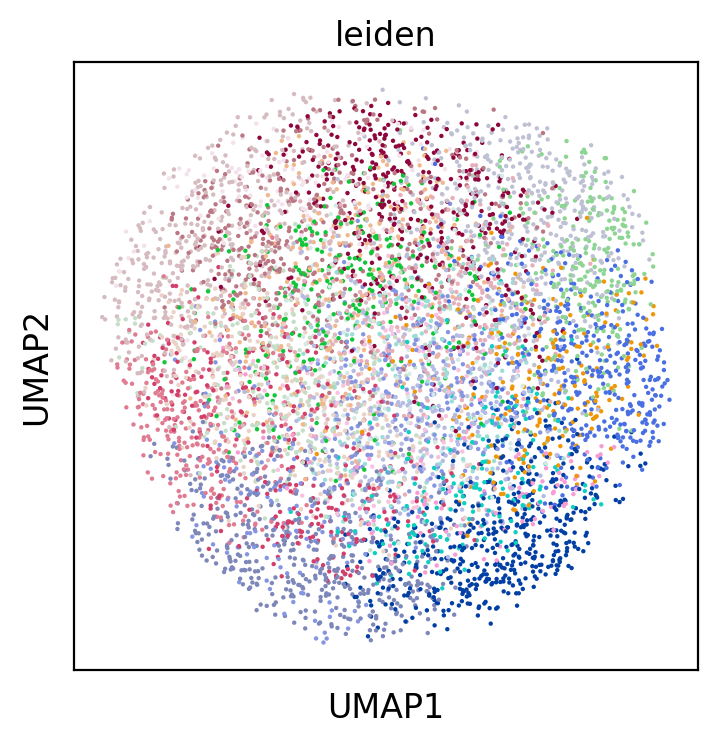

In [7]:
pertEmbedAnndat = pertdec.visualizePerturbationEmbeddings(perturbationEmbeddings, 
                                                          perturbationsList,
                                                          clusteringRes=1.5)

In [8]:
selectedGuides, df = pertdec.selectWorkingGuides(pertEmbedAnndat, 
                                                 controlGuideIdentifiers=["NTC"],
                                                 numberOfGuidesPerTarget=4,
                                                 pValThreshold=0.05,
                                                 correlationThreshold = 0,
                                                 method='pearson')

In [9]:
controlGuides = list(adata.obs.loc[[x.split("_")[0] in "NTC" for x in adata.obs["full_guide_id"]],"full_guide_id"].unique())
controlGuides.sort()

In [10]:
inGuides = selectedGuides + controlGuides + ["adenocarcinoma", "NEPC"]

In [11]:
adata_selected = adata[[x in inGuides for x in adata.obs["full_guide_id"]]]

In [12]:
adata_selected.obs["SelectedPerturbations"] = [x.split("_")[0]  for x in adata_selected.obs["full_guide_id"]]

/tmp/ipykernel_13713/4059793591.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_selected.obs["SelectedPerturbations"] = [x.split("_")[0]  for x in adata_selected.obs["full_guide_id"]]


In [ ]:
pertdec.inferEffectSizes(adata=adata_selected, perturbationsColumn="SelectedPerturbations",
                         referenceLevel="NTC", covariates=["n_genes", "mt_frac", "log10_n_umis" ],
                         par_test_target_interval = 250)

Processing batch starting at index 0
Processing batch starting at index 250
Processing batch starting at index 500
Processing batch starting at index 750
Processing batch starting at index 1000
Processing batch starting at index 1250
Processing batch starting at index 1500
